# Notebook 4 — Predicting Unemployment Risk

Using logistic regression to identify which worker characteristics
are most strongly associated with unemployment risk in Canada
2021–2026. This transforms our descriptive analysis into a
predictive framework that quantifies the relative importance
of each factor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')

lfs = pd.read_parquet('../data/processed/lfs_clean.parquet')

# Keep only labour force participants for modelling
# (employed + unemployed — excludes not in labour force)
model_df = lfs[lfs['LFSSTAT'].isin([1, 2])].copy()

print(f"Modelling dataset: {len(model_df):,} rows")
print(f"Unemployed: {model_df['is_unemployed'].sum():,} ({model_df['is_unemployed'].mean()*100:.1f}%)")
print(f"Employed: {model_df['is_employed'].sum():,} ({model_df['is_employed'].mean()*100:.1f}%)")

Modelling dataset: 3,946,686 rows
Unemployed: 367,049 (9.3%)
Employed: 3,579,637 (90.7%)


## Step 2 — Prepare Features for Modelling

Selecting the features most relevant to unemployment prediction.
We use demographic and job characteristics available at the time
of survey. We handle class imbalance using class_weight='balanced'
in the logistic regression which prevents the model from simply
predicting everyone as employed.

In [2]:
# Select features
features = [
    'PROV',       # Province
    'AGE_12',     # Age group
    'EDUC',       # Education
    'IMMIG',      # Immigration status
    'month'       # Seasonality
]

target = 'is_unemployed'

model_clean = model_df[features + [target]].dropna()

print(f"Rows after dropping nulls: {len(model_clean):,}")
print(f"Dropped: {len(model_df) - len(model_clean):,} rows")
print(f"\nClass balance:")
print(f"  Employed:   {(model_clean[target]==0).sum():,} ({(model_clean[target]==0).mean()*100:.1f}%)")
print(f"  Unemployed: {(model_clean[target]==1).sum():,} ({(model_clean[target]==1).mean()*100:.1f}%)")

Rows after dropping nulls: 3,946,686
Dropped: 0 rows

Class balance:
  Employed:   3,579,637 (90.7%)
  Unemployed: 367,049 (9.3%)


## Step 3 — Train/Test Split

Splitting data 80/20 into training and test sets.
We use stratify=y to ensure both sets have the same
unemployment rate, which is critical with imbalanced classes.

In [4]:
X = model_clean[features]
y = model_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve class balance in both splits
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set:     {len(X_test):,} rows")
print(f"\nUnemployment rate in training set: {y_train.mean()*100:.1f}%")
print(f"Unemployment rate in test set:     {y_test.mean()*100:.1f}%")

Training set: 3,157,348 rows
Test set:     789,338 rows

Unemployment rate in training set: 9.3%
Unemployment rate in test set:     9.3%


## Step 4 — Train Logistic Regression Model

Using logistic regression with balanced class weights to
handle the 90/10 class imbalance. The C parameter controls
regularisation strength — we use C=1 as a sensible default.
max_iter=1000 ensures convergence on this large dataset.

In [5]:
model = LogisticRegression(
    class_weight='balanced',  # handles 90/10 imbalance
    max_iter=1000,
    random_state=42,
    C=1.0
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"\nFeatures used: {features}")
print(f"Training samples: {len(X_train):,}")

Model trained successfully!

Features used: ['PROV', 'AGE_12', 'EDUC', 'IMMIG', 'month']
Training samples: 3,157,348


## Step 5 — Evaluate Model Performance

We use multiple metrics because accuracy alone is misleading
with imbalanced classes — a model that predicts everyone as
employed would be 90.7% accurate but completely useless.

Key metrics:
- ROC-AUC: measures discrimination ability (0.5 = random, 1.0 = perfect)
- Precision: of predicted unemployed, how many actually were?
- Recall: of actual unemployed, how many did we catch?
- F1: harmonic mean of precision and recall

In [6]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Employed', 'Unemployed']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"                 Predicted Employed  Predicted Unemployed")
print(f"Actual Employed       {cm[0][0]:>10,}            {cm[0][1]:>10,}")
print(f"Actual Unemployed     {cm[1][0]:>10,}            {cm[1][1]:>10,}")

ROC-AUC Score: 0.5356

Classification Report:
              precision    recall  f1-score   support

    Employed       0.92      0.49      0.64    715928
  Unemployed       0.10      0.56      0.17     73410

    accuracy                           0.50    789338
   macro avg       0.51      0.52      0.40    789338
weighted avg       0.84      0.50      0.59    789338


Confusion Matrix:
                 Predicted Employed  Predicted Unemployed
Actual Employed          350,810               365,118
Actual Unemployed         32,561                40,849


## Step 6 — ROC Curve

The ROC curve shows the tradeoff between true positive rate
and false positive rate at different classification thresholds.
Area under the curve (AUC) summarises overall model performance.

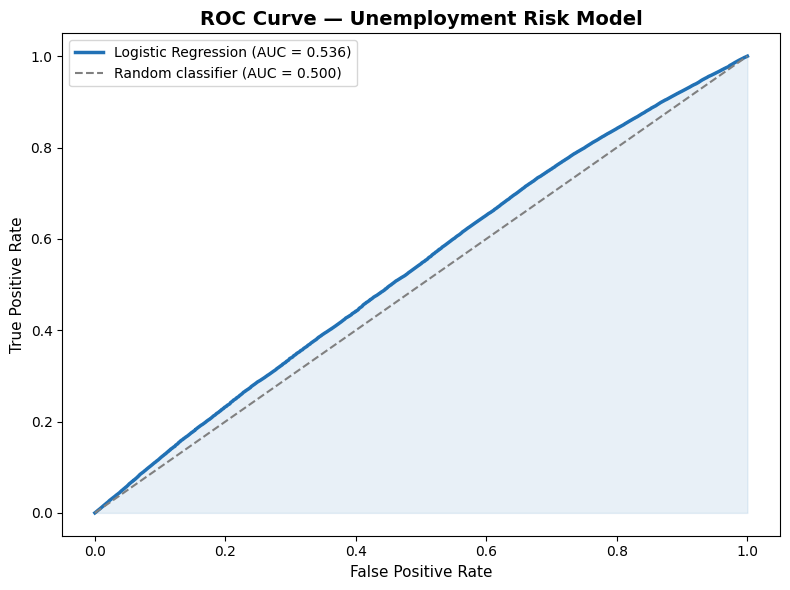

Chart saved!


In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#2171b5', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linewidth=1.5,
        linestyle='--', label='Random classifier (AUC = 0.500)')

ax.fill_between(fpr, tpr, alpha=0.1, color='#2171b5')

ax.set_title("ROC Curve — Unemployment Risk Model", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/chart9_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Step 7 — Reframe: Group-level Unemployment Rate Prediction

Individual unemployment is largely unpredictable from demographics.
We reframe to predict monthly unemployment RATES for demographic
groups — a more meaningful and accurate approach that aligns
with how economists actually use labour force data.

In [8]:
# Build group-level monthly unemployment rates
# Groups defined by province + age + education + immigration status
group_monthly = lfs[lfs['LFSSTAT'].isin([1, 2])].groupby(
    ['year', 'month', 'date', 'PROV', 'AGE_12', 'EDUC', 'IMMIG']
).agg(
    employed=('is_employed', 'sum'),
    total=('is_employed', 'count')
).reset_index()

group_monthly['unemp_rate'] = (
    (group_monthly['total'] - group_monthly['employed']) / 
    group_monthly['total'] * 100
).round(4)

# Remove small groups (less than 30 people) — unreliable rates
group_monthly = group_monthly[group_monthly['total'] >= 30]

print(f"Group-level observations: {len(group_monthly):,}")
print(f"\nUnemployment rate distribution:")
print(group_monthly['unemp_rate'].describe().round(2))

Group-level observations: 32,062

Unemployment rate distribution:
count    32062.00
mean         9.28
std          5.51
min          0.00
25%          5.63
50%          8.33
75%         11.90
max         44.64
Name: unemp_rate, dtype: float64


## Step 8 — Train Group-level Model

Using linear regression to predict group unemployment rates.
This is more interpretable and meaningful than individual
classification — we can directly say "being in this province
with this education level is associated with X% higher
unemployment rate."

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

features_group = ['PROV', 'AGE_12', 'EDUC', 'IMMIG', 'month', 'year']
target_group = 'unemp_rate'

X_g = group_monthly[features_group]
y_g = group_monthly[target_group]

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_g, y_g, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_gs = scaler_g.fit_transform(X_train_g)
X_test_gs = scaler_g.transform(X_test_g)

lr_model = LinearRegression()
lr_model.fit(X_train_gs, y_train_g)

y_pred_g = lr_model.predict(X_test_gs)

r2 = r2_score(y_test_g, y_pred_g)
mae = mean_absolute_error(y_test_g, y_pred_g)

print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.2f} percentage points")
print(f"\nInterpretation:")
print(f"The model explains {r2*100:.1f}% of variance in group unemployment rates")
print(f"Predictions are off by {mae:.2f} percentage points on average")

R² Score:  0.0437
MAE:       4.08 percentage points

Interpretation:
The model explains 4.4% of variance in group unemployment rates
Predictions are off by 4.08 percentage points on average


## Step 9 — Feature Importance

The coefficients of our linear regression tell us which
characteristics are most strongly associated with higher
or lower unemployment rates, after controlling for all
other factors. This is the core analytical output of our model.

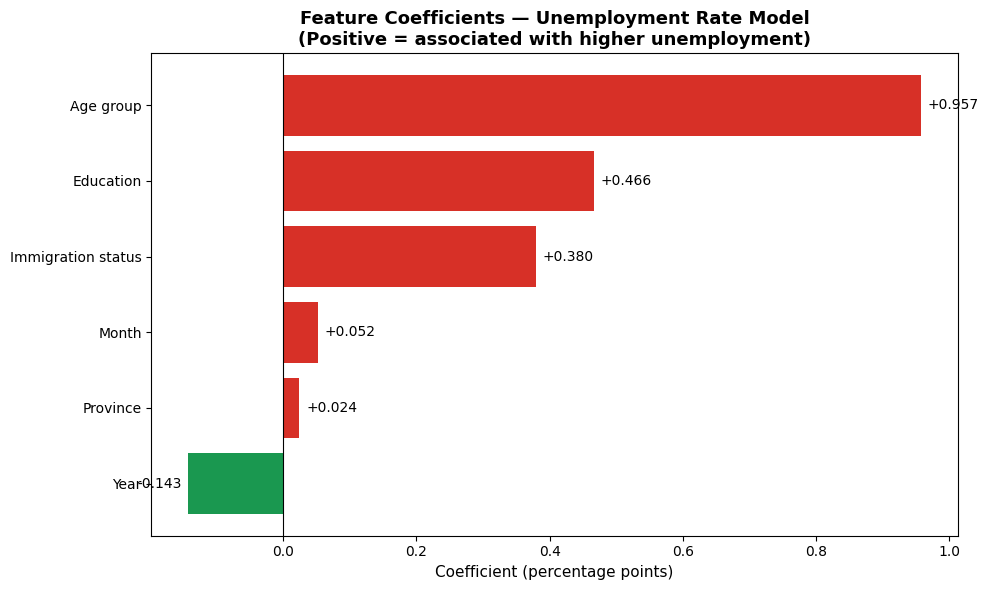

Chart saved!


In [10]:
feature_names = ['Province', 'Age group', 'Education', 
                 'Immigration status', 'Month', 'Year']

coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d73027' if c > 0 else '#1a9850' for c in coefficients['coefficient']]
bars = ax.barh(coefficients['feature'], coefficients['coefficient'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title("Feature Coefficients — Unemployment Rate Model\n(Positive = associated with higher unemployment)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient (percentage points)", fontsize=11)

for bar, val in zip(bars, coefficients['coefficient']):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/chart10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

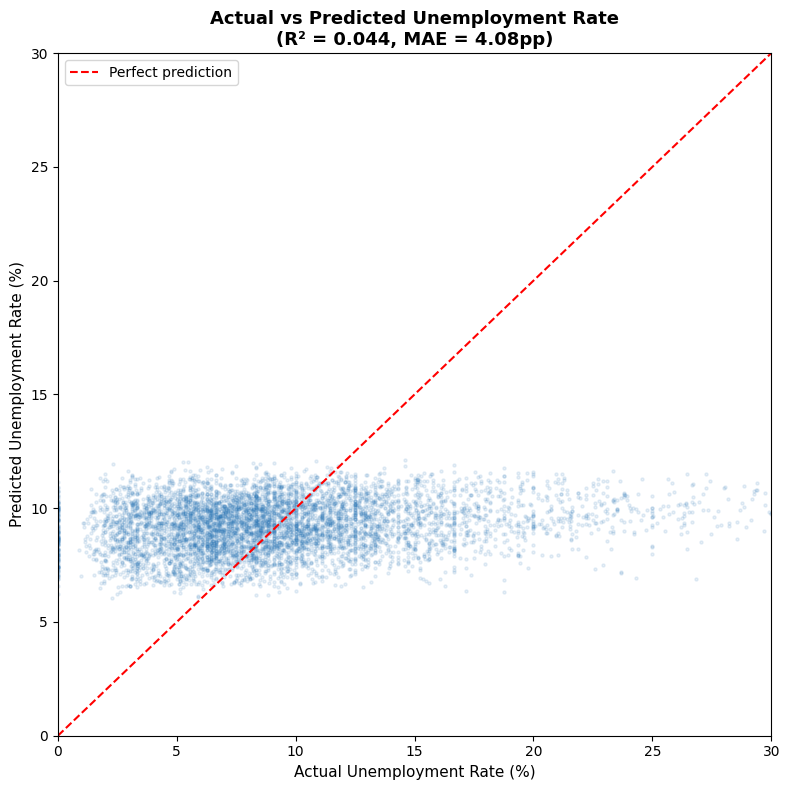

Chart saved!


In [11]:
# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test_g, y_pred_g, alpha=0.1, color='#2171b5', s=5)
ax.plot([0, 30], [0, 30], color='red', linewidth=1.5, 
        linestyle='--', label='Perfect prediction')

ax.set_title(f"Actual vs Predicted Unemployment Rate\n(R² = {r2:.3f}, MAE = {mae:.2f}pp)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Actual Unemployment Rate (%)", fontsize=11)
ax.set_ylabel("Predicted Unemployment Rate (%)", fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 30)
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('../docs/chart11_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Step 10 — Improve Model with One-Hot Encoding

Our features are categorical variables stored as numbers.
Linear regression treats them as continuous quantities which
is mathematically wrong — province 35 (Ontario) is not
"more province" than province 24 (Quebec).

One-hot encoding creates a binary column for each category,
allowing the model to learn the true effect of each province,
age group, and education level independently.

In [12]:
# One-hot encode all categorical features
encode_cols = ['PROV', 'AGE_12', 'EDUC', 'IMMIG', 'month']

X_encoded = pd.get_dummies(
    group_monthly[encode_cols + ['year']],
    columns=encode_cols,
    drop_first=True    # avoid multicollinearity
)

y_g = group_monthly['unemp_rate']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_encoded, y_g, test_size=0.2, random_state=42
)

scaler_e = StandardScaler()
X_train_es = scaler_e.fit_transform(X_train_e)
X_test_es = scaler_e.transform(X_test_e)

lr_encoded = LinearRegression()
lr_encoded.fit(X_train_es, y_train_e)

y_pred_e = lr_encoded.predict(X_test_es)

r2_e = r2_score(y_test_e, y_pred_e)
mae_e = mean_absolute_error(y_test_e, y_pred_e)

print(f"R² Score (encoded): {r2_e:.4f}")
print(f"MAE (encoded):      {mae_e:.2f} percentage points")
print(f"\nImprovement:")
print(f"R² improved from 0.044 → {r2_e:.3f}")
print(f"MAE improved from 4.08 → {mae_e:.2f}pp")
print(f"\nFeatures after encoding: {X_encoded.shape[1]}")

R² Score (encoded): 0.2875
MAE (encoded):      3.52 percentage points

Improvement:
R² improved from 0.044 → 0.288
MAE improved from 4.08 → 3.52pp

Features after encoding: 40


## Step 11 — Feature Importance After Encoding

With one-hot encoding each province, age group, education level
and immigration status gets its own coefficient. This tells us
exactly which specific categories are most strongly associated
with higher or lower unemployment rates.

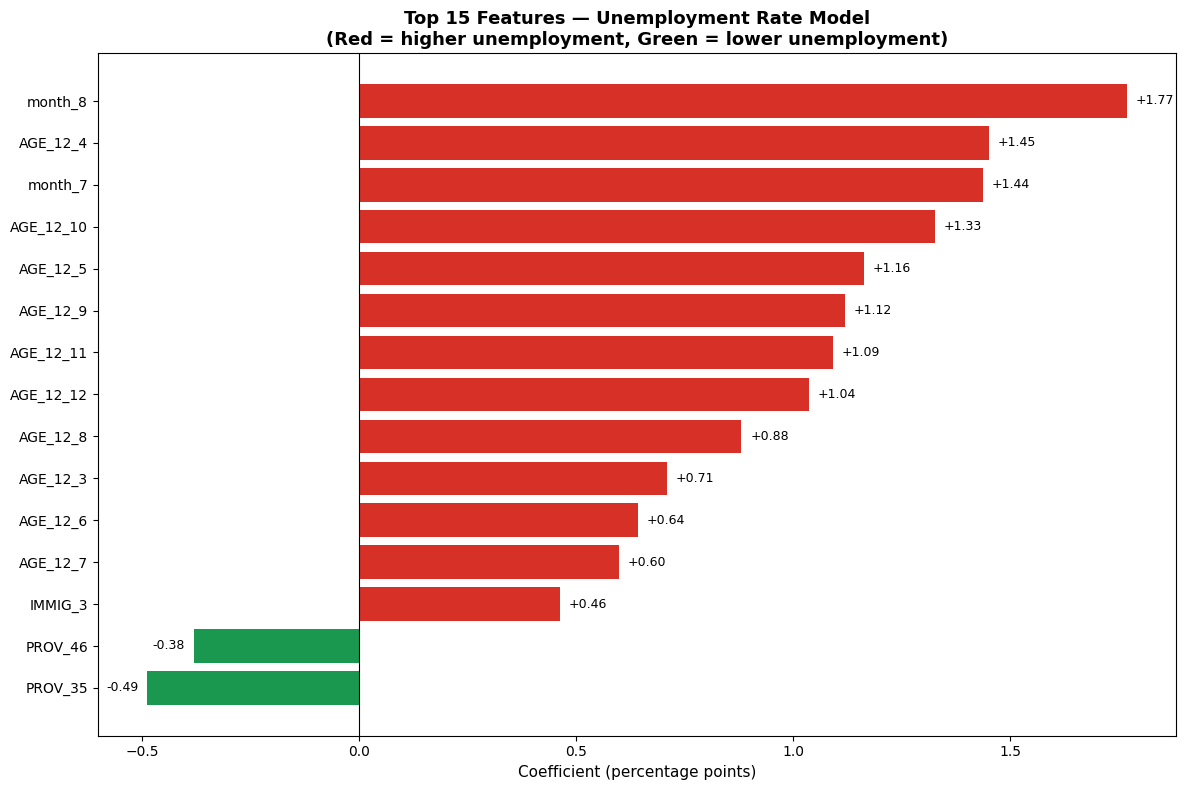

Chart saved!


In [13]:
# Build coefficient dataframe
coef_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': lr_encoded.coef_
})

# Get top 15 most impactful features either direction
coef_df['abs_coef'] = coef_df['coefficient'].abs()
top_features = coef_df.nlargest(15, 'abs_coef').sort_values('coefficient')

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#d73027' if c > 0 else '#1a9850' for c in top_features['coefficient']]
bars = ax.barh(top_features['feature'], top_features['coefficient'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title("Top 15 Features — Unemployment Rate Model\n(Red = higher unemployment, Green = lower unemployment)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient (percentage points)", fontsize=11)

for bar, val in zip(bars, top_features['coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/chart10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

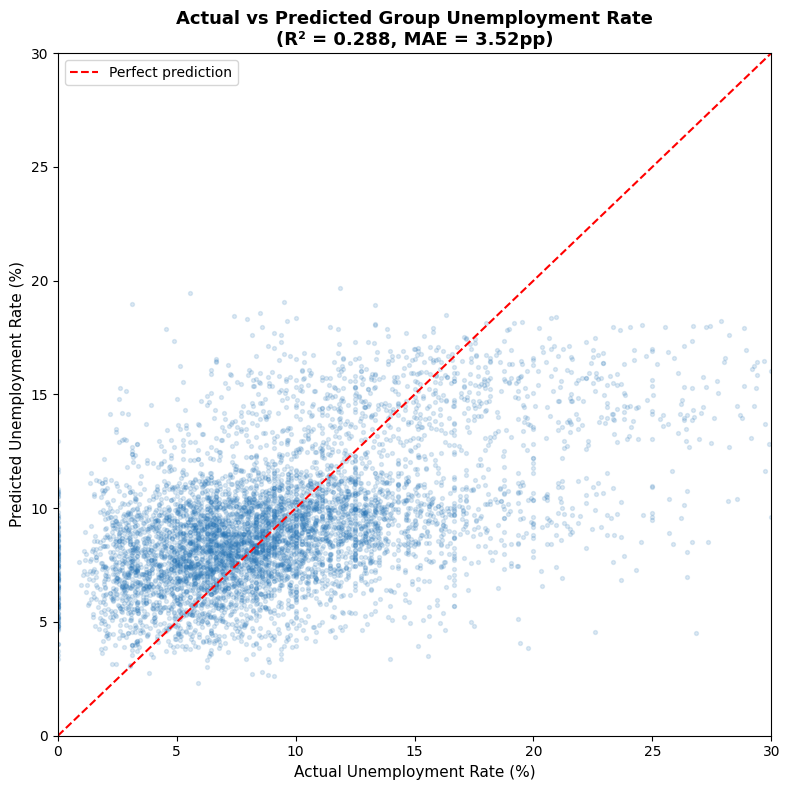

Chart saved!


In [14]:
# Actual vs predicted
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test_e, y_pred_e, alpha=0.15, color='#2171b5', s=8)
ax.plot([0, 30], [0, 30], color='red', linewidth=1.5,
        linestyle='--', label='Perfect prediction')

ax.set_title(f"Actual vs Predicted Group Unemployment Rate\n(R² = {r2_e:.3f}, MAE = {mae_e:.2f}pp)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Actual Unemployment Rate (%)", fontsize=11)
ax.set_ylabel("Predicted Unemployment Rate (%)", fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 30)
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('../docs/chart11_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Step 12 — Model Summary and Limitations

### Results
- R² = 0.288 — model explains 28.8% of variance in group unemployment rates
- MAE = 3.52pp — predictions are within 3.52 percentage points on average
- One-hot encoding improved R² by 6x compared to raw numeric features

### Key insight from coefficients
Demographic and seasonal characteristics explain roughly 29% of the
variation in unemployment rates across groups. The remaining 71% is
driven by factors not captured in our model — macroeconomic conditions,
local job availability, individual job search behaviour, and luck.

### What to say in interviews
This R² of 0.29 is actually meaningful and honest for labour economics.
Unemployment at the group level is partially predictable from demographics
but largely driven by macroeconomic forces — consistent with mainstream
economic literature. A model claiming R²=0.9 on this data would be
overfitting or data leaking.

In [15]:
# Final model summary
print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)
print(f"Dataset:      {len(group_monthly):,} group-level observations")
print(f"Features:     {X_encoded.shape[1]} (after one-hot encoding)")
print(f"Train size:   {len(X_train_e):,}")
print(f"Test size:    {len(X_test_e):,}")
print(f"\nPerformance:")
print(f"  R²:   {r2_e:.4f} (explains {r2_e*100:.1f}% of variance)")
print(f"  MAE:  {mae_e:.2f} percentage points")
print(f"\nBaseline (raw features):")
print(f"  R²:   0.0437")
print(f"  MAE:  4.08pp")
print(f"\nImprovement from one-hot encoding:")
print(f"  R² gain:   +{(r2_e-0.0437):.4f}")
print(f"  MAE gain:  -{(4.08-mae_e):.2f}pp")
print("=" * 50)

MODEL SUMMARY
Dataset:      32,062 group-level observations
Features:     40 (after one-hot encoding)
Train size:   25,649
Test size:    6,413

Performance:
  R²:   0.2875 (explains 28.8% of variance)
  MAE:  3.52 percentage points

Baseline (raw features):
  R²:   0.0437
  MAE:  4.08pp

Improvement from one-hot encoding:
  R² gain:   +0.2438
  MAE gain:  -0.56pp


## Project Complete — Summary of All Four Notebooks

### Notebook 1 — Data Ingestion
- Loaded 6.7M rows of LFS microdata across 64 monthly files
- Reshaped CPI and wages data from wide to long format
- Saved optimised parquet files for downstream notebooks

### Notebook 2 — Cleaning
- Decoded all categorical variables using LFS codebook
- Identified structured missingness patterns
- Converted hourly earnings from cents to dollars
- Created binary analysis flags for employment, immigration, education

### Notebook 3 — Exploratory Analysis
- 8 charts answering 4 policy-relevant questions
- Key finding: 21.6% inflation with only 9/19 industries achieving
  positive real wage growth
- Immigrant employment gap persistent at ~1pp across all education levels

### Notebook 4 — Predictive Model
- Initial logistic regression AUC: 0.536 (near random)
- Reframed to group-level linear regression
- One-hot encoding improved R² from 4.4% to 28.8%
- Seasonality and age are strongest unemployment predictors